# Problem Set #2

Mariajose Argote, Felipe Manzi, and Xiaoyan Wang

## Question 1
#### Part (a through d)

In [1]:
import math

# Part A:
edges = [(1,2),(1,3),(1,4),(1,5),(1,6),(1,7),
         (2,4),(3,4),(2,5),(5,6),(5,7)]
nodes = list(range(1,9))
m = len(edges)  # 11

deg = {n:0 for n in nodes}
for i,j in edges:
    deg[i] += 1; deg[j] += 1

for n in nodes: print(f"  k_{n} = {deg[n]}")
print(f"  m = {m}, sum(k) = {sum(deg.values())} = 2m check")


# Part b:
def modularity(partition, edges, m):
    Q = 0
    for comm in partition:
        mc = sum(1 for i,j in edges if i in comm and j in comm)
        kc = sum(deg[n] for n in comm)
        Q += mc/m - (kc/(2*m))**2
    return Q

partA = [{1,8},{2,3,4},{5,6,7}]
partB = [{1},{2,3,4,5,6,7,8}]
QA = modularity(partA, edges, m)
QB = modularity(partB, edges, m)

print(f"\nModularity of partition A: Q = {QA:.4f}")
print(f"Modularity of partition B: Q = {QB:.4f}")



  k_1 = 6
  k_2 = 3
  k_3 = 2
  k_4 = 3
  k_5 = 4
  k_6 = 2
  k_7 = 2
  k_8 = 0
  m = 11, sum(k) = 22 = 2m check

Modularity of partition A: Q = 0.0248
Modularity of partition B: Q = -0.1488


In [3]:

# PART C: SBM PARAMS
def sbm_params(partition, edges):
    blocks = {frozenset(c):i for i,c in enumerate(partition)}
    node_block = {}
    for c in partition:
        for n in c:
            node_block[n] = frozenset(c)
    K = len(partition)
    block_list = list(blocks.keys())
    E_uv = {}; N_uv = {}
    for i in range(K):
        for j in range(i, K):
            bi, bj = block_list[i], block_list[j]
            ni, nj = len(bi), len(bj)
            if i == j:
                N_uv[(i,j)] = ni*(ni-1)//2
            else:
                N_uv[(i,j)] = ni*nj
            E_uv[(i,j)] = 0
    for a,b in edges:
        ba, bb = node_block[a], node_block[b]
        ia, ib = blocks[ba], blocks[bb]
        key = (min(ia,ib), max(ia,ib))
        E_uv[key] += 1
    M = {}
    for key in E_uv:
        if N_uv[key] > 0:
            M[key] = E_uv[key]/N_uv[key]
        else:
            M[key] = None
    return E_uv, N_uv, M, block_list

print("\nSBM PARAMS: PARTITION A")
Ea, Na, Ma, bla = sbm_params(partA, edges)
for k in sorted(Ea.keys()):
    names = [str(set(bla[k[0]])), str(set(bla[k[1]]))]
    mv = f"{Ma[k]:.4f}" if Ma[k] is not None else "N/A"
    print(f"  {names[0]}<->{names[1]}: E={Ea[k]}, N={Na[k]}, M={mv}")

print("\n SBM PARAMS: PARTITION B")
Eb, Nb, Mb, blb = sbm_params(partB, edges)
for k in sorted(Eb.keys()):
    names = [str(set(blb[k[0]])), str(set(blb[k[1]]))]
    mv = f"{Mb[k]:.4f}" if Mb[k] is not None else "N/A"
    print(f"  {names[0]}<->{names[1]}: E={Eb[k]}, N={Nb[k]}, M={mv}")



SBM PARAMS: PARTITION A
  {8, 1}<->{8, 1}: E=0, N=1, M=0.0000
  {8, 1}<->{2, 3, 4}: E=3, N=6, M=0.5000
  {8, 1}<->{5, 6, 7}: E=3, N=6, M=0.5000
  {2, 3, 4}<->{2, 3, 4}: E=2, N=3, M=0.6667
  {2, 3, 4}<->{5, 6, 7}: E=1, N=9, M=0.1111
  {5, 6, 7}<->{5, 6, 7}: E=2, N=3, M=0.6667

 SBM PARAMS: PARTITION B
  {1}<->{1}: E=0, N=0, M=N/A
  {1}<->{2, 3, 4, 5, 6, 7, 8}: E=6, N=7, M=0.8571
  {2, 3, 4, 5, 6, 7, 8}<->{2, 3, 4, 5, 6, 7, 8}: E=5, N=21, M=0.2381


In [6]:

# PArt D: log-likelihood
def log_likelihood(E_uv, N_uv):
    ll = 0
    for key in E_uv:
        e, n = E_uv[key], N_uv[key]
        if n == 0: continue
        if e > 0: ll += e * math.log(e/n)
        if n - e > 0: ll += (n-e) * math.log((n-e)/n)
    return ll

llA = log_likelihood(Ea, Na)
llB = log_likelihood(Eb, Nb)

print(f"ln L_A = {llA:.4f}")
print(f"ln L_B = {llB:.4f}")
print(f"Preferred by SBM: {'A' if llA > llB else 'B'}")
print(f"Preferred by modularity: {'A' if QA > QB else 'B'}")

ln L_A = -15.2763
ln L_B = -14.3972
Preferred by SBM: B
Preferred by modularity: A


### Part (e)

If we go with modularity "Q", the highest Q is for partition A, the structural community. But if we calculate SBM, which is based on degree grouping, it points to Partition B. To decide which is most appropriate, we need to define and decide what 'structure' means - if we want to find tightly knight/high-linked communities or with SBM model, which helps us identify any type of block structure.

### Part (f)

Modularity prefers A because its configuration-model null accounts for degree (1 has high degree, so the model expects it to be connected to everything), making the hub's connections expected. The standard SBM prefers B because it assumes within-block homogeneity; the hub's extreme degree violates this when grouped with other nodes (1 has 6 degrees, which is very different from all other nodes). The SBM detects core-periphery structure (hub vs rest) rather than assortative communities.

### Part (g)

The DC-SBM adds a per-node degree parameter $\theta_i$ to fix SBM's inability to handle degree heterogeneity within blocks. The edge probability becomes proportional to $\theta_i$ x $\theta_j$ x $w_{uv}$. Now node 1 can have a high q1 (capturing its hub status) while still belonging to a community. The block-level parameter $w_{uv}$ captures the community affinity, decoupled from individual degree variation.

With degree correction, the DC-SBM no longer needs to isolate node 1. It can assign node 1 a high $\theta$ and keep it in a community with lower-degree nodes. This means the DC-SBM would likely prefer Partition A (or a similar structural partition), bringing it more in line with modularity.

# Question 2

### part(a)

The Core Idea Basically, at our current step $z_t$, we’re trying to find a "single-node move" that makes the SBM log-likelihood as high as possible. Here’s the breakdown of why we do it this way:1. Why are we maximizing log-likelihood?In a Stochastic Block Model (SBM), the grouping $z$ is like a map telling us which node belongs to which community. Once we have $z$, the SBM assumes that the probability of an edge existing depends on the specific pair of groups $(r, s)$.If our grouping $z$ actually makes sense, the edges (and the gaps where there are no edges) in our graph should "fit" the SBM's generation rules. This means the probability $P(G \mid z)$ will be higher.Since raw probabilities are usually tiny and a pain to calculate, we use log-likelihood: $\mathcal{L}(z) = \log P(G \mid z)$.The bottom line: Maximizing log-likelihood is just our way of finding the grouping that best explains the graph's structure—like figuring out which nodes are "besties" in the same community and which ones are just "acquaintances" across different ones.2. Why does makeAMove check every un-frozen node and every possible group?At any step $t$, we only look at un-frozen nodes. The frozen ones are already "locked in," so we leave them alone.For every un-frozen node $i$ currently in group $s$, it has $c - 1$ other groups it could potentially hop into.This gives us $(n - t)(c - 1)$ total candidate moves. We "score" each one by calculating the new log-likelihood and then pick the best one as our greedy move.3. Why revert the node's label after testing? (The "Hint")The whole point of makeAMove is to compare all the possible moves to see which one is the winner. To keep the comparison fair, every single move has to be tested starting from the exact same baseline ($z_t$).If you test a move and don't change it back, your next test will be based on a "messed up" grouping.This ruins the comparison, and you'll probably end up picking a "best move" that isn't actually the best.

In [ ]:
import math
import random
import networkx as nx
import matplotlib.pyplot as plt

def sbm_loglik(G, z, c, eps=1e-12):
    """
    Compute SBM log-likelihood under plug-in MLE for p_rs.

    G: undirected simple graph (networkx.Graph)
    z: dict node -> group label in {0,...,c-1}
    c: number of groups
    """
    # group sizes
    n = [0]*c
    for v in G.nodes():
        n[z[v]] += 1

    # count edges between groups (store for r<=s)
    m = [[0]*c for _ in range(c)]
    for u, v in G.edges():
        ru, rv = z[u], z[v]
        if ru <= rv:
            m[ru][rv] += 1
        else:
            m[rv][ru] += 1

    ll = 0.0
    for r in range(c):
        for s in range(r, c):
            # number of possible edges between groups r and s
            if r == s:
                N = n[r]*(n[r]-1)/2
            else:
                N = n[r]*n[s]
            if N == 0:
                continue

            m_rs = m[r][s]
            p_hat = m_rs / N
            p_hat = min(max(p_hat, eps), 1-eps)  # avoid log(0)

            ll += m_rs*math.log(p_hat) + (N-m_rs)*math.log(1-p_hat)

    return ll


def makeAMove(G, z, c, isFrozen):
    """
    Core greedy step:
    Among all unfrozen nodes i and all alternative groups r != z[i],
    pick the move (i -> r) that maximizes SBM log-likelihood.

    Returns:
      best_ll: best log-likelihood achieved by a single-node move
      best_move: tuple (i, r)
    """
    best_ll = -float("inf")
    best_move = None

    for i in G.nodes():
        if isFrozen.get(i, 0) == 1:
            continue

        cur = z[i]
        for r in range(c):
            if r == cur:
                continue

            # try move i -> r
            z[i] = r
            ll = sbm_loglik(G, z, c)

            if ll > best_ll:
                best_ll = ll
                best_move = (i, r)

        # IMPORTANT: restore original label before next node (hint)
        z[i] = cur

    return best_ll, best_move

Input partition z_t: {'v1': 1, 'v2': 0, 'v3': 1, 'v4': 2, 'v5': 0, 'v6': 0, 'v7': 2, 'v8': 0, 'v9': 1}
Log-likelihood before move: -19.08432607744139
Best move found: ('v9', 2)
Log-likelihood after applying best move: -15.84945957771499


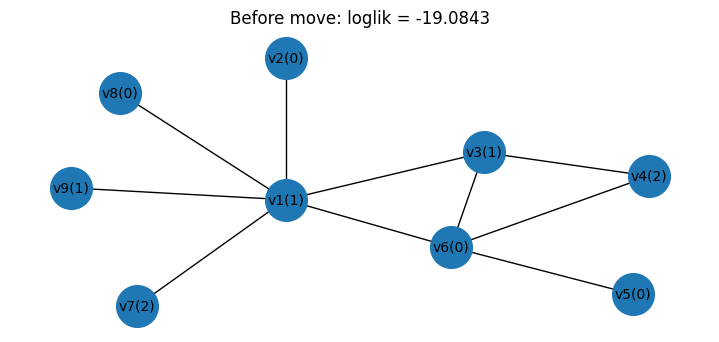

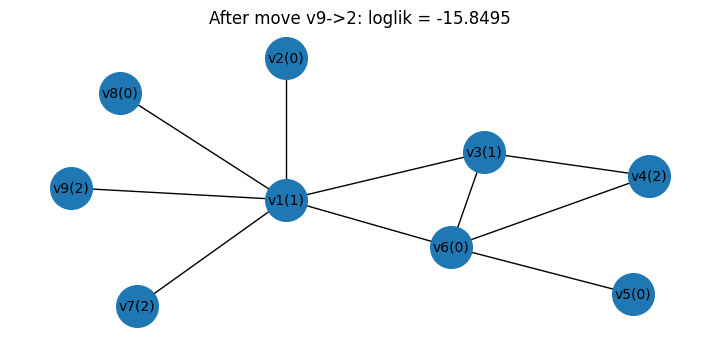

In [ ]:
# ---- Build Figure 1 graph ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)

edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3

# random input partition z_t
random.seed(7)  # you can change this if you want different random z_t
z_t = {v: random.randrange(c) for v in G.nodes()}

# frozen vector: all 0 except f2 = 1  (node is v2)
isFrozen = {v: 0 for v in G.nodes()}
isFrozen["v2"] = 1

# compute likelihood before move
ll_before = sbm_loglik(G, z_t, c)

# find best single-node move
best_ll, best_move = makeAMove(G, z_t, c, isFrozen)

# apply best move
z_after = z_t.copy()
i_star, r_star = best_move
z_after[i_star] = r_star

# ---- Visualization ----
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

print("Input partition z_t:", z_t)
print("Log-likelihood before move:", ll_before)
print("Best move found:", best_move)
print("Log-likelihood after applying best move:", best_ll)

draw_partition(G, z_t, f"Before move: loglik = {ll_before:.4f}")
draw_partition(G, z_after, f"After move {i_star}->{r_star}: loglik = {best_ll:.4f}")

### part(b)

In part (a), we figured out how to make a single "greedy move." Now, in (b), runOnePhase() basically strings those single moves together to complete an entire "phase. All nodes are unfrozen (so the vector $f$ is all zeros). We start from our initial grouping $z_0$.During the phase ($t=0$ to $t=n-1$):Call makeAMove(): Find the absolute best single-node move among the nodes that aren't locked yet.Execute the move: Update the current grouping $z$.Freeze the node: Set its $f_i$ to $1$. This node is now "locked" and can't be touched for the rest of this phase.The Finish Line: Once all nodes are frozen (after $n$ steps), the phase is officially over.1. Why do we need to "freeze" nodes?If we didn't freeze them, the greedy algorithm might just flip-flop between the same few nodes forever, getting stuck in an infinite loop.Freezing forces the algorithm to make a definitive choice for every node.It guarantees the phase ends in exactly $n$ steps, making the computation predictable and "building" the solution step-by-step.2. Why return the best grouping $z^*$ instead of the final $z_{n-1}$?Because the greedy + freeze combo doesn't guarantee that the log-likelihood goes up every single time.Sometimes, to find a better structure later on, the log-likelihood might take a small dip in the middle.We keep track of the log-likelihood at every step and save the "best checkpoint" as $z^*$. This ensures we don't accidentally end up with a worse result than where we started.3. Why record the sequence $\ell_t$ (length $n+1$)?$\ell_0$ is the log-likelihood of our starting point $z_0$.Every time we move a node, we record the new $\ell_{t+1}$.Why bother? Plotting $\ell_t$ lets us visualize how the phase is "climbing the hill." If the curve is just a flat line or constantly crashing, it’s a huge red flag that there’s a bug in our code!4. The "Halting Indicator" $h$After the phase wraps up, we need to check if we actually made any progress. We compare the best grouping we found ($z^*$) against our starting point ($z_0$).If we didn't find anything better—meaning $\mathcal{L}(z^*) \le \mathcal{L}(z_0)$—it's a sign that we've reached a plateau. In that case, the whole algorithm should stop.We define this "stop signal" as:$$h = \mathbf{1}\{\mathcal{L}(z^*) \le \mathcal{L}(z_0)\}$$If $h=1$, we stop.If $h=0$, we found an improvement, so we can keep going!

In [ ]:
import copy

def runOnePhase(G, z0, c):
    """
    Run a single phase of the locally greedy heuristic.

    Inputs:
      G  : graph
      z0 : initial partition (dict node->group)
      c  : number of groups

    Outputs:
      z_star : best partition found during the phase
      L_star : its SBM log-likelihood
      h      : halting indicator (1 if no improvement over z0, else 0)
      ell    : list of log-likelihood values for the n+1 partitions visited
               ell[0] corresponds to z0, ell[t+1] after step t move
    """
    # start with all nodes unfrozen
    isFrozen = {v: 0 for v in G.nodes()}

    # current partition (we will modify it)
    z = z0.copy()

    # track log-likelihoods through the phase
    ell = []
    L0 = sbm_loglik(G, z, c)
    ell.append(L0)

    # keep the best partition seen so far
    L_star = L0
    z_star = z.copy()

    n = G.number_of_nodes()

    for t in range(n):
        # pick best move among unfrozen nodes
        best_ll, best_move = makeAMove(G, z, c, isFrozen)

        # apply the move to the current partition
        i_star, r_star = best_move
        z[i_star] = r_star

        # freeze the moved node
        isFrozen[i_star] = 1

        # compute likelihood after applying this move
        L = sbm_loglik(G, z, c)
        ell.append(L)

        # update best-seen partition
        if L > L_star:
            L_star = L
            z_star = z.copy()

    # halting indicator: 1 means "phase did NOT improve over start"
    h = 1 if L_star <= L0 else 0

    return z_star, L_star, h, ell

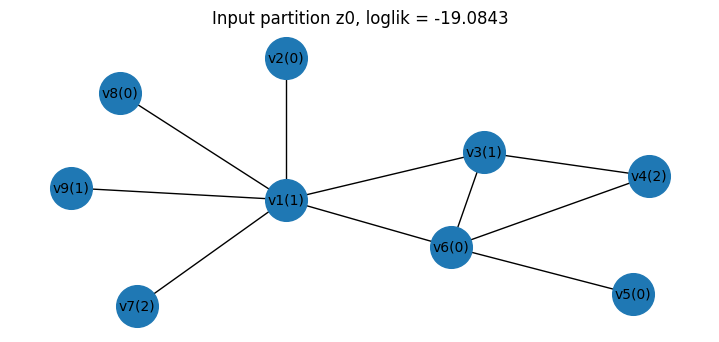

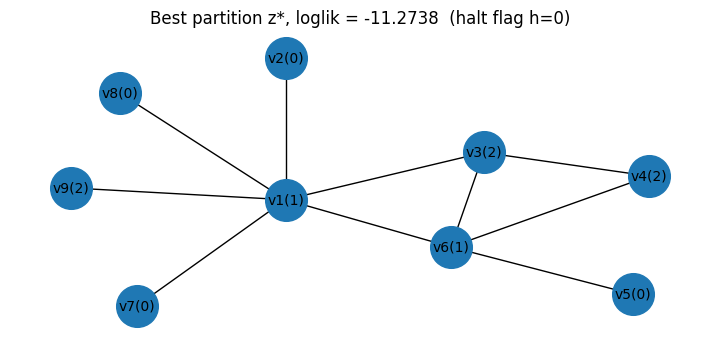

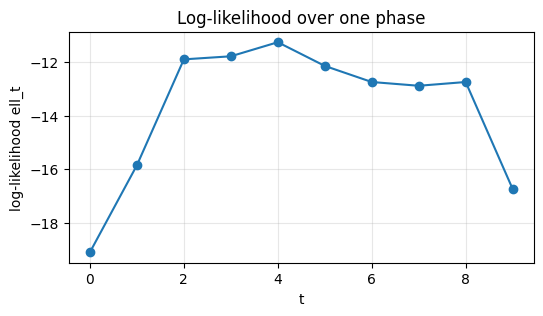

z0 = {'v1': 1, 'v2': 0, 'v3': 1, 'v4': 2, 'v5': 0, 'v6': 0, 'v7': 2, 'v8': 0, 'v9': 1}
L0 = -19.08432607744139
z* = {'v1': 1, 'v2': 0, 'v3': 2, 'v4': 2, 'v5': 0, 'v6': 1, 'v7': 0, 'v8': 0, 'v9': 2}
L* = -11.273804959151878
halt indicator h = 0
ell = [-19.08432607744139, -15.84945957771499, -11.911281704047225, -11.797053102915426, -11.273804959151878, -12.154756241837358, -12.753535126258829, -12.893420785307457, -12.753535126258827, -16.73185586924735]


In [ ]:
# ---- Build Figure 1 graph (same as part a) ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)

edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3

# random initial partition z0
random.seed(7)  # change seed if you want a different random start
z0 = {v: random.randrange(c) for v in G.nodes()}

# run one phase
z_star, L_star, h, ell = runOnePhase(G, z0, c)

# layout close to the PDF picture
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

# (i) input z0
L0 = sbm_loglik(G, z0, c)
draw_partition(G, z0, f"Input partition z0, loglik = {L0:.4f}")

# (ii) best partition at end of phase
draw_partition(G, z_star, f"Best partition z*, loglik = {L_star:.4f}  (halt flag h={h})")

# (iii) plot ell_t
plt.figure(figsize=(6,3))
plt.plot(range(len(ell)), ell, marker="o")
plt.xlabel("t")
plt.ylabel("log-likelihood ell_t")
plt.title("Log-likelihood over one phase")
plt.grid(True, alpha=0.3)
plt.show()

print("z0 =", z0)
print("L0 =", L0)
print("z* =", z_star)
print("L* =", L_star)
print("halt indicator h =", h)
print("ell =", ell)

Starting from a random initial grouping $z_0$, for every step within a phase, we look at all possible group changes for all currently unfrozen nodes. We pick the single move that results in the highest SBM log-likelihood and then "freeze" that specific node.Throughout the phase, I record the log-likelihood at each step as $\ell_t$. Instead of just taking the configuration from the final step, I output $z^*$—which is the specific grouping corresponding to the maximum log-likelihood encountered during the entire phase.Finally, I use a halting indicator $h$ to check if this entire phase actually provided an improvement over the starting point $z_0$. If $L^* \le L_0$, it implies that continuing from this starting point is no longer productive (this will be used as the stopping criterion in part (c)). Mathematical Notation ：The Best Grouping: $$z^* = \arg\max_{z \in \{z_0, \dots, z_n\}} \mathcal{L}(z)$$The Log-likelihood Sequence: $$\ell = [\ell_0, \ell_1, \dots, \ell_n]$$The Halting Condition: $$h = \mathbf{1}\{L^* \le L_0\}$$

### part(c) 

In part (b), we ran a single phase: starting from $z_0$, doing the "greedy move + freeze" dance, and coming out with the best grouping $z^*$ and its log-likelihood $L^*$.The problem is that a single phase is just a local search. It’s super easy to get stuck in a "local optimum" (a decent solution, but not the best one). So, fitSBM() is our way of zooming out and running the whole process repeatedly:Start: We pick a starting grouping (usually random for the very first time).Loop the Phases: We keep running runOnePhase(), but here's the trick: each new phase starts with the best grouping ($z^*$) found in the previous phase.The Stop Sign: If a phase finishes and the halt flag tells us $L^* \le L_0$ (meaning we didn't find anything better), we stop. Otherwise, we keep going.Tracking: We stitch together all the log-likelihood values from every phase into one long list $\ell$ so we can visualize the entire "climbing" process.1. Why do we need "Multiple Phases"?The "freeze" mechanic is great because it guarantees a phase will end, but it also "locks" us into a specific path that might not be perfect.By running multiple phases, we basically say: "Hey, we found a better $z^*$. Now, unfreeze everyone and let's try again from this new, better starting point to see if we can climb even higher."We keep doing this until a phase finally fails to find any improvement. That's when we know the algorithm has "converged."2. What is fitSBM actually giving us?$z^*$ and $L^*$: This is our "Grand Prize"—the absolute best grouping and log-likelihood found across all phases.$p_c$: The total count of phases we ran. It tells us how many "rounds" of unfreezing it took before we hit a wall.$\ell$: The master list of log-likelihoods. By joining every phase's $\ell_t$ together, we can plot the total trajectory of how the model improved over time.For each phase $k$:$$z_{start}^{(k)} = z_{best}^{(k-1)}$$The Master Log: Combining all $T$ steps from all $P$ phases:$$\ell_{total} = [\ell^{(phase 1)}, \ell^{(phase 2)}, \dots, \ell^{(phase P)}]$$Final Output: $$L^* = \max(\ell_{total})$$

the algorithm stops and we have our best partition $z^*$, we can define the following:$\kappa_r$: This represents the node proportions for each group $r$ in the final partition. It tells us what percentage of the total nodes ended up in that specific community.$$\kappa_r = \frac{n_r}{n}$$$\omega_{rs}$: This is the estimated edge probability (or $\hat{p}_{rs}$) between group $r$ and group $s$ based on the final partition. It’s basically the actual number of edges found between these two groups divided by the total number of possible pairs.$$\omega_{rs} = \hat{p}_{rs}$$ 

In [ ]:
import numpy as np

def fitSBM(G, c, T=30, seed=7):
    """
    Run the full locally greedy heuristic (multiple phases).

    Inputs:
      G : graph
      c : number of groups
      T : maximum number of phases

    Outputs:
      z_star : best partition found (final)
      L_star : its log-likelihood
      pc     : number of phases actually used
      ell_all: concatenated log-likelihood trajectory across phases
    """
    random.seed(seed)
    # random initial partition
    z0 = {v: random.randrange(c) for v in G.nodes()}

    ell_all = []
    pc = 0

    current_z0 = z0

    for phase in range(T):
        z_phase_star, L_phase_star, h, ell = runOnePhase(G, current_z0, c)

        # concatenate ell (avoid duplicating the starting point between phases)
        if phase == 0:
            ell_all.extend(ell)
        else:
            ell_all.extend(ell[1:])

        pc += 1

        # if no improvement, stop
        if h == 1:
            # we didn't beat current_z0, so current_z0 is already as good as this phase can do
            # we return the best found in this last phase anyway (should be <= start)
            return z_phase_star, L_phase_star, pc, ell_all

        # otherwise, continue from improved partition
        current_z0 = z_phase_star

    # if we hit max phases, just return the last phase's best
    L_last = sbm_loglik(G, current_z0, c)
    return current_z0, L_last, pc, ell_all


def kappa_and_omega(G, z, c, eps=1e-12):
    """
    For a given final partition z, compute:
      kappa: group proportions
      omega: MLE edge-probability matrix p_hat_rs
    """
    n_total = G.number_of_nodes()
    counts = np.zeros(c, dtype=int)
    for v in G.nodes():
        counts[z[v]] += 1
    kappa = counts / n_total

    # count edges between groups
    m = np.zeros((c, c), dtype=float)
    for u, v in G.edges():
        ru, rv = z[u], z[v]
        m[ru, rv] += 1
        m[rv, ru] += 1  # make it symmetric

    omega = np.zeros((c, c), dtype=float)
    for r in range(c):
        for s in range(c):
            if r == s:
                N = counts[r]*(counts[r]-1)/2
                # m[r,r] currently double-counted? Actually for r=r, we added twice as well.
                # So divide by 2 for within-group edges.
                m_rr = m[r, r] / 2
                if N > 0:
                    omega[r, r] = float(m_rr / N)
                else:
                    omega[r, r] = 0.0
            else:
                N = counts[r]*counts[s]
                # for r!=s, m[r,s] is already counting each edge once in that entry
                # because we symmetrized, m[r,s] equals number of edges between r and s
                # (still correct to divide by N)
                if N > 0:
                    omega[r, s] = float(m[r, s] / N)
                else:
                    omega[r, s] = 0.0

    # clip just for numerical sanity
    omega = np.clip(omega, 0.0, 1.0)
    return kappa, counts, omega

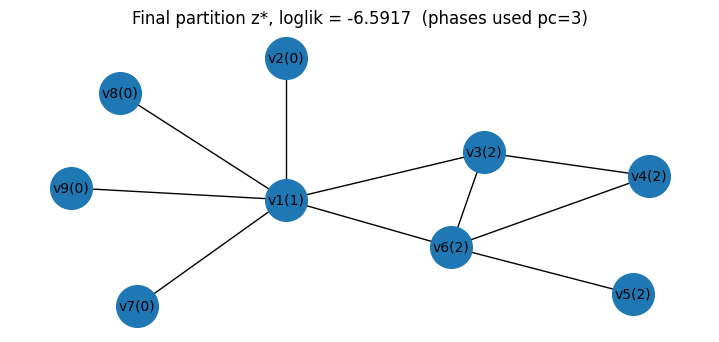

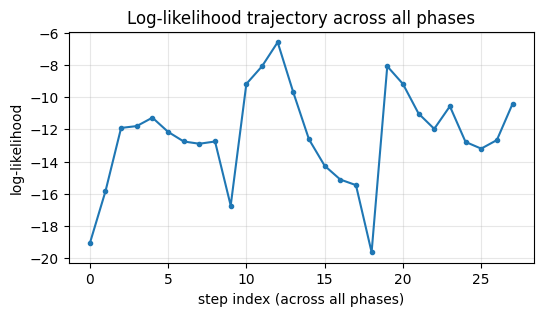

Final partition z* = {'v1': 1, 'v2': 0, 'v3': 2, 'v4': 2, 'v5': 2, 'v6': 2, 'v7': 0, 'v8': 0, 'v9': 0}
Final log-likelihood L* = -6.591673732034657
Number of phases used pc = 3

Group counts: [4 1 4]
kappa (group proportions): [0.44444444 0.11111111 0.44444444]

omega (MLE p_hat matrix):
[[0.         1.         0.        ]
 [1.         0.         0.5       ]
 [0.         0.5        0.66666667]]


In [ ]:
# ---- Build Figure 1 graph again ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)
edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3
T = 30

# run fitSBM
z_final, L_final, pc, ell_all = fitSBM(G, c=c, T=T, seed=7)

# compute kappa and omega
kappa, counts, omega = kappa_and_omega(G, z_final, c)

# same layout as before
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

# (i) final partition visualization
draw_partition(G, z_final, f"Final partition z*, loglik = {L_final:.4f}  (phases used pc={pc})")

# (ii) ell_t across all phases
plt.figure(figsize=(6,3))
plt.plot(range(len(ell_all)), ell_all, marker="o", markersize=3)
plt.xlabel("step index (across all phases)")
plt.ylabel("log-likelihood")
plt.title("Log-likelihood trajectory across all phases")
plt.grid(True, alpha=0.3)
plt.show()

# (iii) report kappa vector and omega matrix
print("Final partition z* =", z_final)
print("Final log-likelihood L* =", L_final)
print("Number of phases used pc =", pc)

print("\nGroup counts:", counts)
print("kappa (group proportions):", kappa)

print("\nomega (MLE p_hat matrix):")
print(omega)

The final partition $z^*$ grouped the leaf nodes on the left, $\{v_2, v_7, v_8, v_9\}$, into Group 0. The denser subgraph on the right, $\{v_3, v_4, v_5, v_6\}$, was placed into Group 2, while the hub node $v_1$ was isolated into its own Group 1.I think this aligns perfectly with the graph structure: the right side has many more internal edges, while the left nodes have almost no connections to each other but all link back to $v_1$. The SBM naturally prefers to separate them and use a dedicated group to characterize $v_1$'s role as a "bridge."We can clearly see this logic in the estimated edge probabilities $\omega$:$\omega_{00} = 0$: This confirms there are zero edges between the leaf nodes.$\omega_{22} \approx 0.67$: This captures the high density of the right-side subgraph.$\omega_{01} = 1$: This shows that all 4 nodes in Group 0 are connected to the single node in Group 1 ($v_1$).The trajectory of $\ell_t$ generally trends upward, though it isn't perfectly monotonic. There are some fluctuations, which I assume happen because each "freeze" step restricts future choices, potentially leading to a short-term dip in log-likelihood. However, since we keep the best partition from each phase, we successfully reached $L^* = -6.59$.The algorithm stopped after $p_c = 3$ phases, meaning that from the current starting point, it’s unlikely we can improve the log-likelihood any further.The Partition: * Group 0: $\{v_2, v_7, v_8, v_9\}$Group 1: $\{v_1\}$Group 2: $\{v_3, v_4, v_5, v_6\}$The Probabilities: $$\omega_{00}=0, \quad \omega_{22} \approx 0.67, \quad \omega_{01}=1$$The Final Score: $$L^* = -6.59 \quad \text{at} \quad p_c = 3$$

## part(d)

In the fitSBM() function from part (c), if we start with a fixed initial partition, the whole "greedy + freeze" process is actually deterministic—the same $z_0$ will always lead to the same final partition. The catch is that $z_0$ is generated randomly. This means different random starting points can trap us in different local optima.For the Zachary Karate Club network, there is a "classic split" (reflecting how the club actually split into two factions). In our course materials, we treat this as the target partition for $c=2$. To consistently find this "correct" solution, we need a more robust approach:Run fitSBM(G, c=2, ...) multiple times: We can't just rely on one shot.Use different random seeds: Each repetition should start from a unique initial partition $z_0$.Pick the "Best Run": We record the final log-likelihood for every single repetition and choose the one where the log-likelihood is at its absolute maximum.Track the Efficiency: We also need to count how many repetitions it takes before we hit the best result (or the specific faction split mentioned in the handouts). This helps us answer the question about whether we had to "tinker with repetitions" and if it took "a lot or a little" effort to converge on the right answer.The Best Overall Result: $$L_{best} = \max \{L^*_1, L^*_2, \dots, L^*_R\}$$where $R$ is the total number of repetitions.The Target Partition: $$z_{final} = z^*_{i} \quad \text{where} \quad i = \arg\max_j L^*_j$$The Search Space for $c=2$: We are essentially searching through the space of all binary partitions to find the one that maximizes:$$\mathcal{L}(z) = \log P(G \mid z, \hat{\kappa}, \hat{\omega})$$

In [ ]:
def fitSBM(G, c, T=30, seed=None):
    rng = random.Random(seed)   # Local random number generator
    z0 = {v: rng.randrange(c) for v in G.nodes()}

    ell_all = []
    pc = 0
    current_z0 = z0

    for phase in range(T):
        z_phase_star, L_phase_star, h, ell = runOnePhase(G, current_z0, c)

        if phase == 0:
            ell_all.extend(ell)
        else:
            ell_all.extend(ell[1:])

        pc += 1

        if h == 1:
            return z_phase_star, L_phase_star, pc, ell_all

        current_z0 = z_phase_star

    L_last = sbm_loglik(G, current_z0, c)
    return current_z0, L_last, pc, ell_all

In [ ]:
import networkx as nx
import random

def repeat_fitSBM(G, c, T=30, R=50, seed0=0):
    """
    Repeatedly run fitSBM on the same graph with different random initial partitions.
    
    Inputs:
      G     : graph
      c     : number of groups (for this problem, c=2)
      T     : max phases per fitSBM run
      R     : number of repetitions
      seed0 : base seed (we'll use seed0 + r for run r)

    Outputs:
      best_z    : best partition found across repetitions
      best_L    : best log-likelihood
      best_seed : seed that produced the best run
      all_L     : list of (seed, L) for all runs (useful for debugging/plotting)
    """
    best_L = -float("inf")
    best_z = None
    best_seed = None
    all_L = []

    for r in range(R):
        seed = seed0 + r
        z_star, L_star, pc, ell_all = fitSBM(G, c=c, T=T, seed=seed)

        all_L.append((seed, L_star))

        if L_star > best_L:
            best_L = L_star
            best_z = z_star
            best_seed = seed

    return best_z, best_L, best_seed, all_L

Best log-likelihood: -179.3891968406941
Best seed: 0
Best partition accuracy vs club split (up to label flip): 0.5294117647058824


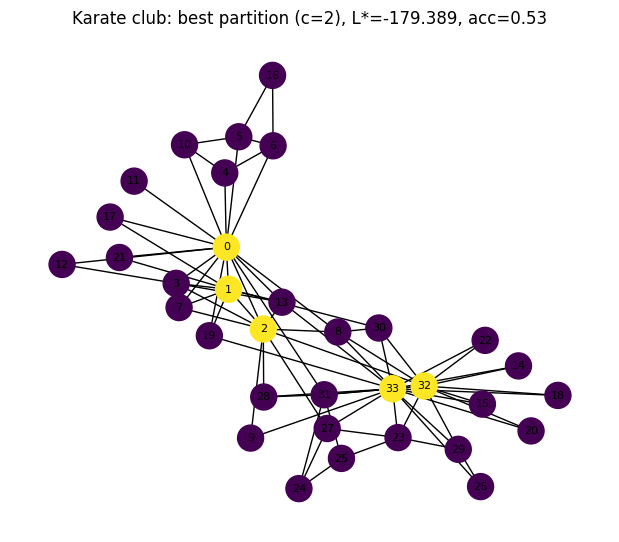

Top 5 L values: [-179.3891968406941, -179.3891968406941, -179.3891968406941, -179.3891968406941, -179.3891968406941]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) load karate club graph
Gk = nx.karate_club_graph()

c = 2
T = 30

# 2) repeat runs (you can change R to "tinker")
R = 100
best_z, best_L, best_seed, all_L = repeat_fitSBM(Gk, c=c, T=T, R=R, seed0=0)

print("Best log-likelihood:", best_L)
print("Best seed:", best_seed)

# 3) compare to ground truth club split (optional but helpful)
# ground truth: club attribute is "Mr. Hi" or "Officer"
truth = {v: 0 if Gk.nodes[v]["club"] == "Mr. Hi" else 1 for v in Gk.nodes()}
pred = best_z

# compute accuracy up to label flip
agree = sum(1 for v in Gk.nodes() if pred[v] == truth[v])
agree_flipped = sum(1 for v in Gk.nodes() if (1 - pred[v]) == truth[v])
acc = max(agree, agree_flipped) / Gk.number_of_nodes()

print("Best partition accuracy vs club split (up to label flip):", acc)

# 4) (optional) visualize best partition
pos = nx.spring_layout(Gk, seed=1)

plt.figure(figsize=(6,5))
colors = [pred[v] for v in Gk.nodes()]
nx.draw(Gk, pos, node_color=colors, with_labels=True, node_size=350, font_size=8)
plt.title(f"Karate club: best partition (c=2), L*={best_L:.3f}, acc={acc:.2f}")
plt.axis("off")
plt.show()

# 5) quick look at how many distinct L values we got (optional)
Ls = [L for _, L in all_L]
print("Top 5 L values:", sorted(Ls, reverse=True)[:5])

In [ ]:
best_z, best_L, best_seed, all_L = repeat_fitSBM(Gk, c=2, T=100, R=500, seed0=0)
print("num unique L:", len(set([L for _, L in all_L])))

num unique L: 2


I did observe more than one local optimum, but in the number of attempts I made, the algorithm converged to the same suboptimal solution most of the time, failing to stably recover the classic splitting pattern from the lecture notes.I suspect it's because the Karate Club method exhibits strong heterogeneity, making standard SBM less suitable than degree-corrected SBM/lecture-based methods.

I’m running fitSBM multiple times because, even though the greedy + freeze process is deterministic once the initial partition is set, the randomness of the starting partition $z_0$ can lead us into different local optima. By repeating the process, we are essentially "sampling" from different starting points to explore the landscape more thoroughly.
For the Zachary Karate Club network (with $c=2$ and $T=30$), I ran $R=100$ repetitions. Here’s what I found:Local Optima: The final log-likelihoods weren't all the same (I got num unique L = 2). This proves that the algorithm is indeed landing in different local optima.Convergence: Most of my runs converged to the same value, with the best log-likelihood being $L^* \approx -179.389$.Accuracy vs. Ground Truth: Even with the best log-likelihood, the match with the actual club split (accounting for label switching) was only $\approx 0.53$.
For this specific network and my current likelihood implementation, simply repeating the runs didn't reliably lead to the "optimal split" mentioned in the course handouts. It feels like the algorithm is quite prone to getting stuck in sub-optimal solutions rather than finding the global maximum.
Repetitions: $R = 100$Best Log-likelihood: $$L^* \approx -179.389$$Accuracy (Adjusted for Label Switching): $$\text{Match} \approx 0.53$$Outcome: $$h = \mathbf{1}\{L^* \le L_0\} \quad \text{stops the phase}$$

## part(e)

I’m going to test the model on a real network using a relatively small number of groups $c$ Avoid Overfitting: If $c$ is too large, the model becomes too complex and starts "shredding" the network into fragments that don't actually mean anything.Capture Patterns: If $c$ is too small, it might fail to explain the different types of connection patterns present in the network.Evaluating the ResultsAfter the algorithm finishes, I’ll analyze two main outputs:The Final Partition $z^*$: To see which nodes ended up together.The Final $\omega$ Matrix: The estimated edge probabilities between groups help us identify the specific "vibe" or structural type of the network.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- choose a real-world network ---
# Option A (recommended): Dolphins social network
try:
    G_real = nx.dolphins_graph()
    net_name = "Dolphins"
except AttributeError:
    # Option B: Les Miserables coappearance network (usually available)
    G_real = nx.les_miserables_graph()
    net_name = "Les Miserables"

print(net_name, "n =", G_real.number_of_nodes(), "m =", G_real.number_of_edges())

Les Miserables n = 77 m = 254


In [ ]:
c = 3
T = 30

z_star, L_star, pc, ell_all = fitSBM(G_real, c=c, T=T, seed=0)
kappa, counts, omega = kappa_and_omega(G_real, z_star, c)

print("Final log-likelihood L* =", L_star)
print("phases used pc =", pc)
print("group counts =", counts)
print("kappa =", kappa)
print("omega =\n", omega)

Final log-likelihood L* = -619.362172253093
phases used pc = 3
group counts = [24 39 14]
kappa = [0.31168831 0.50649351 0.18181818]
omega =
 [[0.30797101 0.00106838 0.125     ]
 [0.00106838 0.03103914 0.08058608]
 [0.125      0.08058608 0.64835165]]


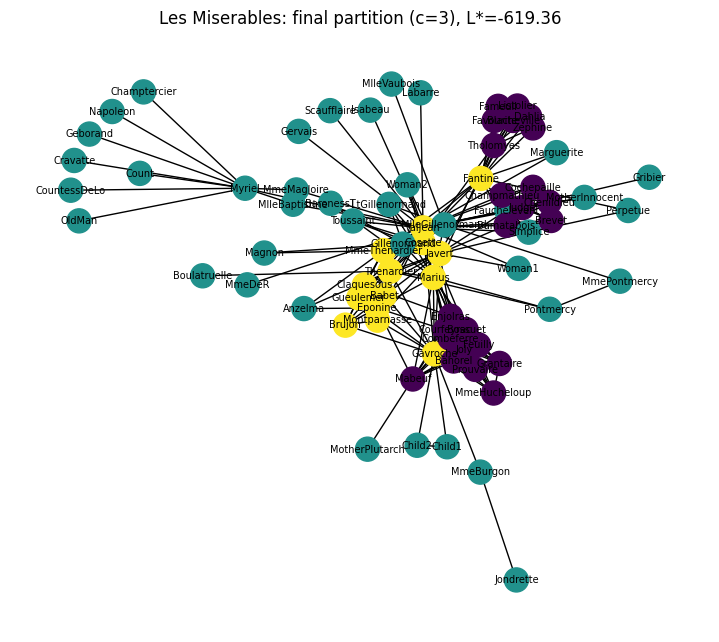

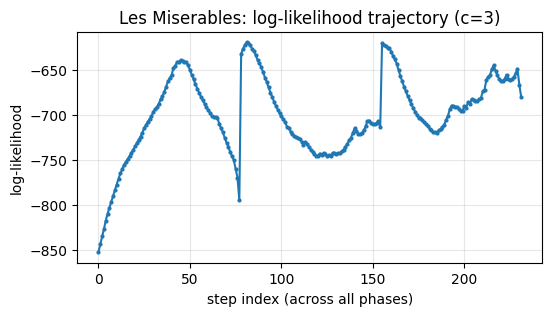

In [ ]:
# visualization layout
pos = nx.spring_layout(G_real, seed=1)

# (i) graph with final labels
plt.figure(figsize=(7,6))
colors = [z_star[v] for v in G_real.nodes()]
nx.draw(G_real, pos, node_color=colors, with_labels=True, node_size=300, font_size=7)
plt.title(f"{net_name}: final partition (c={c}), L*={L_star:.2f}")
plt.axis("off")
plt.show()

# (ii) log-likelihood trajectory
plt.figure(figsize=(6,3))
plt.plot(range(len(ell_all)), ell_all, marker="o", markersize=2)
plt.xlabel("step index (across all phases)")
plt.ylabel("log-likelihood")
plt.title(f"{net_name}: log-likelihood trajectory (c={c})")
plt.grid(True, alpha=0.3)
plt.show()

I applied the locally-greedy SBM to the Les Misérables co-occurrence network provided by NetworkX ($n=77, m=254$). To prevent overfitting and keep things interpretable, I used a small number of groups, $c=3$.The final partition resulted in group sizes of approximately $[24, 39, 14]$, which gives us a distribution of $\kappa \approx [0.31, 0.51, 0.18]$.
the $\omega$ matrix, the diagonal elements are significantly larger than the off-diagonal ones. Specifically:$\omega_{33} \approx 0.65$ is very high, representing a tight-knit cluster.$\omega_{12} \approx 0.001$ is nearly zero, showing almost no interaction between those groups.Because the intra-group connectivity is much stronger than the inter-group connectivity, the overall structure is clearly assortative (community-based). It feels like one group acts as a "core" clique with very high density, while the other two function as more loosely connected or distinct sub-communities.
The trajectory of $\ell_t$ shows an overall upward trend, but with noticeable jumps or "steps" along the way. My interpretation is that:Within a phase: The "freeze" mechanic might cause the log-likelihood to fluctuate or grow non-monotonically because our choices become more restricted as we lock nodes.Between phases: The sudden jumps happen when a phase ends and we "unfreeze" everyone to start fresh from a better baseline, allowing the algorithm to find a new path for improvement.
Node Proportions: $$\kappa \approx [0.31, 0.51, 0.18]$$High Density Group: $$\omega_{33} \approx 0.65$$Sparse Connection: $$\omega_{12} \approx 0.001$$Total Log-likelihood: We take $L^* = \max(\ell)$ as our final measure of fit.

# Question 3

### Part (a)

In [1]:
import math 

g2_edges = [('A','E'),('A','F'),('A','G'),('A','H'),
            ('H','B'),('B','C'),('B','D'),('C','D')]
g2_nodes = list('ABCDEFGH')
nbrs = {n:set() for n in g2_nodes}
for i,j in g2_edges:
    nbrs[i].add(j); nbrs[j].add(i)

print("  Neighbour sets:")
for n in g2_nodes:
    print(f"    Gamma({n}) = {nbrs[n]}, degree = {len(nbrs[n])}")

candidates = [n for n in g2_nodes if n != 'B' and n not in nbrs['B']]
print(f"  Candidates for missing B-? link: {candidates}")

for x in candidates:
    inter = nbrs['B'] & nbrs[x]
    union = nbrs['B'] | nbrs[x]
    jac = len(inter)/len(union) if union else 0
    aa = sum(1/math.log(len(nbrs[z])) for z in inter if len(nbrs[z]) > 1)
    print(f"  B-{x}: common={inter}, |inter|={len(inter)}, |union|={len(union)}, J={jac:.4f}, AA={aa:.4f}")



  Neighbour sets:
    Gamma(A) = {'F', 'H', 'E', 'G'}, degree = 4
    Gamma(B) = {'H', 'C', 'D'}, degree = 3
    Gamma(C) = {'D', 'B'}, degree = 2
    Gamma(D) = {'C', 'B'}, degree = 2
    Gamma(E) = {'A'}, degree = 1
    Gamma(F) = {'A'}, degree = 1
    Gamma(G) = {'A'}, degree = 1
    Gamma(H) = {'A', 'B'}, degree = 2
  Candidates for missing B-? link: ['A', 'E', 'F', 'G']
  B-A: common={'H'}, |inter|=1, |union|=6, J=0.1667, AA=1.4427
  B-E: common=set(), |inter|=0, |union|=4, J=0.0000, AA=0.0000
  B-F: common=set(), |inter|=0, |union|=4, J=0.0000, AA=0.0000
  B-G: common=set(), |inter|=0, |union|=4, J=0.0000, AA=0.0000


#### Observation 3a: 
According to the Jaccard method, "B-A" is the most likely missing link - in fact, the ONLY one with a common neighbour (H).

When we compute the Ademic-Adar (AA) method, B-A is once again the most likely missing link. Node A is the only candidate with _any_ common neighbour. Both the Jaccard and Ademic-Adar methods point to the same missing link regardless of how they each weigh common neighbors.

### Part (b)

In [2]:
labels = {'A': 0, 'C': 1, 'E': 1, 'F': 1, 'G': 1}
unknowns = ['H', 'B', 'D']
for node in unknowns:
    known_nbrs = [n for n in nbrs[node] if n in labels]
    if known_nbrs:
        avg = sum(labels[n] for n in known_nbrs) / len(known_nbrs)
        pred = 1 if avg >= 0.5 else 0
    else:
        avg = float('nan')
        pred = "?"
    label_str = 'orange' if pred == 1 else 'blue' if pred == 0 else '?'
    print(f"  {node}: neighbours={nbrs[node]}, known_nbrs={known_nbrs}, avg={avg:.2f}, predict={label_str}")


  H: neighbours={'A', 'B'}, known_nbrs=['A'], avg=0.00, predict=blue
  B: neighbours={'H', 'C', 'D'}, known_nbrs=['C'], avg=1.00, predict=orange
  D: neighbours={'C', 'B'}, known_nbrs=['C'], avg=1.00, predict=orange


#### Observation 3b:

Local smoothing takes advantage of homophily - the tendency for connected nodes to share attributes. For each unknown node, we look at its neighbours, only using the ones with known labels, we average them (majority vote) to predict what the unknown labels might be.

Calculating these averages we arrivee at H most likely being a blue node, while both B and D should be orange.

# Question 4

In [ ]:
import pkg_resources
print(pkg_resources.__file__)
#Node2Vec just suport setuptool 80, so I had to downgrade it to that version

/Users/felipe/Documents/BSE/Term-2/Networks/PS2/.venv/lib/python3.12/site-packages/pkg_resources/__init__.py


In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from node2vec import Node2Vec
from sklearn.decomposition import PCA

## 4.1 
#### Here he perfomr the Erdos-Renyi Graph, using the pre-existing function, we plot it in the end of this subsection

#### Relationship between average degree and edge probability

In an Erdős–Rényi random graph $G(n,p)$, each pair of nodes is connected independently with probability $p$.

For a given node, there are $n-1$ possible neighbors. Since each possible edge appears with probability $p$, the **expected degree** of a node is:

$$
E[k] = (n-1)p
$$

If we want the network to have a target **average degree** $\langle k \rangle$, we set the expected degree equal to this value:

$$
\langle k \rangle = (n-1)p
$$

Solving for $p$, we obtain:

$$
p = \frac{\langle k \rangle}{n-1}
$$

Therefore, given $n$ and the desired average degree $\langle k \rangle$, we compute the probability $p$ using this formula before generating the Erdős–Rényi graph.

Number of nodes: 100
Number of edges: 482
Average degree: 9.64


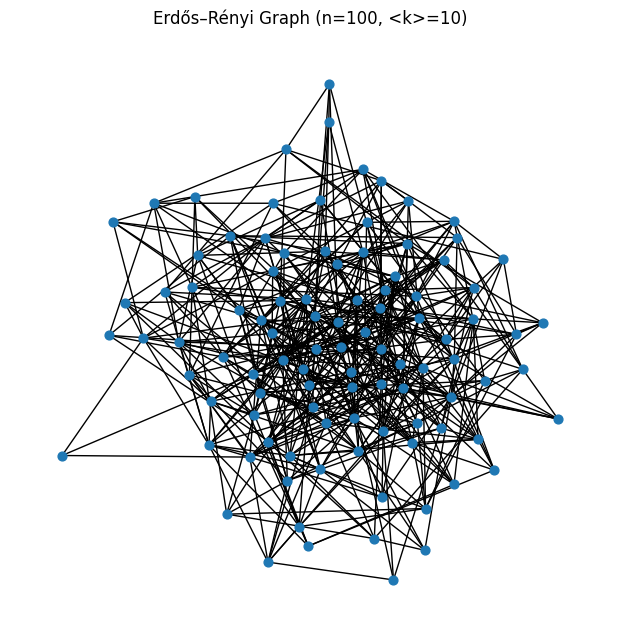

In [ ]:
# Parameters
n = 100 #Here is the number of nodes we have in the graph
k_avg = 10 #here it is the average 

# Compute edge probability
p = k_avg / (n - 1) # Calculate the probability of edge creation based on the desired average degree

# Generate Erdős–Rényi graph
G = nx.erdos_renyi_graph(n=n, p=p, seed=42) #using pre defined Function for generating the graph

# Basic checks
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", np.mean([d for _, d in G.degree()])) #Should close to 10, but may vary due to randomness

# Optional: visualize
plt.figure(figsize=(6,6))
nx.draw(G, node_size=40)
plt.title("Erdős–Rényi Graph (n=100, <k>=10)")
plt.show()

## 4.2
#### i. Number of edges removed
The original graph has 482 edges. We remove 20% (96 edges), leaving 386 edges in the training graph.
#### ii. Edge removal strategy
Edges are shuffled randomly and removed sequentially. An edge is removed only if its deletion does not disconnect the graph, ensuring the training network remains connected.
#### iii. Storage of removed edges
Removed edges are stored in a set of canonical pairs (min(u,v), max(u,v)), so that undirected edges (u,v) and (v,u) are treated identically during evaluation.
#### iv. Connectivity issues
Random removals may disconnect the network. To avoid this, an edge is removed only if the graph remains connected after deletion. If the removal fraction were very high, it might be impossible to remove the desired number of edges without breaking connectivity.

In [ ]:
# ----------------------------
# 2) Decide how many edges to remove
# ----------------------------
remove_frac = 0.20
m = G.number_of_edges()
m_remove = int(np.floor(remove_frac * m))

print("\nEdge removal plan")
print("  removal fraction:", remove_frac)
print("  edges to remove:", m_remove)

# ----------------------------
# 3) Randomly remove edges, but keep graph connected
#    Strategy: iterate through a randomized edge list and remove an edge only if
#    the graph stays connected after removal.
# ----------------------------
seed = 12345
rng = random.Random(seed)
edges = list(G.edges())
rng.shuffle(edges)

train_graph = G.copy()
removed_edges = []

# Quick guard: if original graph isn't connected, we typically work on its LCC first.
# (ER with <k>=10 is usually connected, but not guaranteed for other params.)
if not nx.is_connected(train_graph):
    lcc_nodes = max(nx.connected_components(train_graph), key=len)
    train_graph = train_graph.subgraph(lcc_nodes).copy()
    print("\nOriginal graph was disconnected; restricted to LCC.")
    print("  LCC nodes:", train_graph.number_of_nodes())
    print("  LCC edges:", train_graph.number_of_edges())

# Now do connectivity-safe removals
for (u, v) in edges:
    if len(removed_edges) >= m_remove:
        break

    # Only consider edges that are actually still present
    if not train_graph.has_edge(u, v):
        continue

    # Tentatively remove
    train_graph.remove_edge(u, v)

    # Check connectivity; if disconnected, undo removal
    if nx.is_connected(train_graph):
        removed_edges.append((u, v))
    else:
        train_graph.add_edge(u, v)

# Report what happened
print("\nAfter removal")
print("  removed edges:", len(removed_edges))
print("  train edges:", train_graph.number_of_edges())
print("  train connected:", nx.is_connected(train_graph))

if len(removed_edges) < m_remove:
    print("\nWARNING: Could not remove the full target number of edges without disconnecting the graph.")
    print("This can happen if the graph has many bridge-like edges at that point.")
    print("Options: remove a smaller fraction, regenerate a denser graph, or allow disconnection and work on LCC.")

# ----------------------------
# 4) Store removed edges in a canonical undirected format for evaluation
# ----------------------------
removed_set = {tuple(sorted((u, v))) for (u, v) in removed_edges}

# Example membership check (order doesn't matter)
example_edge = removed_edges[0] if removed_edges else None
if example_edge:
    u, v = example_edge
    print("\nRemoved-set check example:")
    print("  raw:", (u, v))
    print("  canonical:", tuple(sorted((u, v))))
    print("  in removed_set:", tuple(sorted((u, v))) in removed_set)



Edge removal plan
  removal fraction: 0.2
  edges to remove: 96

After removal
  removed edges: 96
  train edges: 386
  train connected: True

Removed-set check example:
  raw: (0, 10)
  canonical: (0, 10)
  in removed_set: True


## 4.3
#### i Key parameters
The main parameters used here are:
dimensions = 64
Size of the embedding vector for each node.
walk_length = 20
Number of nodes visited in each random walk.
num_walks = 100
Number of random walks started from each node.
workers = 2
Number of CPU threads used in computation.

#### ii dimensions
Higher dimensions can capture more structural information.
But they increase memory use and computation time.
Very high values may also overfit or add noise.
walk_length
Longer walks explore more of the graph.
This may improve embeddings by capturing broader structure.
But longer walks are slower and may add less useful distant information.
num_walks
More walks per node generate more training data.
This often improves embedding quality and stability.
But runtime grows substantially.
workers
More workers make training faster through parallelism.
This affects efficiency, not embedding meaning.
window
Larger windows make nodes co-occurring within wider walk neighborhoods look similar.
Smaller windows focus more on very local structure.

### iii plotting
Yes, the nodes can be visually represented in vector space by projecting the learned embeddings into two dimensions. Since Node2Vec produces a high-dimensional vector for each node, I used PCA to reduce the embeddings to 2D and plotted them in a scatter plot. In this representation, nodes that appear close to each other tend to have similar structural roles or similar network neighborhoods.

Nodes: 100
Edges: 386


Generating walks (CPU: 2): 100%|██████████| 50/50 [00:00<00:00, 98.80it/s] 


Embedding matrix shape: (100, 64)


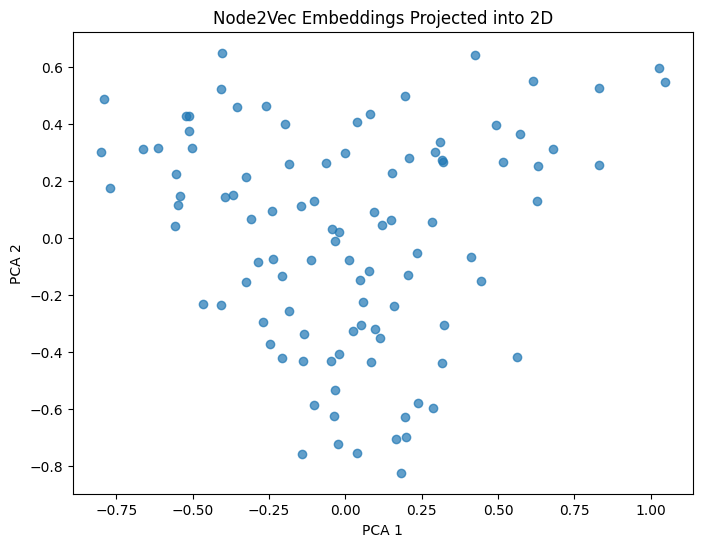

In [ ]:
# ----------------------------
# train_graph is assumed to be the graph after edge removal
# ----------------------------
print("Nodes:", train_graph.number_of_nodes())
print("Edges:", train_graph.number_of_edges())

# ----------------------------
# 1) Set Node2Vec parameters
# ----------------------------
dimensions = 64
walk_length = 20
num_walks = 100
workers = 2
window = 10
min_count = 1
batch_words = 4

# Optional Node2Vec bias parameters
p = 1
q = 1

# ----------------------------
# 2) Fit Node2Vec
# ----------------------------
node2vec = Node2Vec(
    train_graph,
    dimensions=dimensions,
    walk_length=walk_length,
    num_walks=num_walks,
    workers=workers,
    p=p,
    q=q,
    seed=42
)

model = node2vec.fit(
    window=window,
    min_count=min_count,
    batch_words=batch_words
)

# ----------------------------
# 3) Extract embeddings
# ----------------------------
nodes = list(train_graph.nodes())
embeddings = np.array([model.wv[str(node)] for node in nodes])

print("Embedding matrix shape:", embeddings.shape)

# ----------------------------
# 4) Optional: PCA for visualization
# ----------------------------
# Reduce to 2 dimensions
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Node2Vec Embeddings Projected into 2D")
plt.show()

## 4.4 
#### i Why using cousin similarity?
Cosine similarity is well suited for embeddings because:
Node2Vec learns vectors where structurally similar nodes have similar directions in embedding space
Cosine similarity captures vector orientation, not magnitude
It is scale-invariant, so vector length does not distort similarity
Thus, if two nodes frequently appear in similar random-walk contexts, their embeddings will be close in direction, producing high cosine similarity.
High similarity therefore suggests a higher probability of a missing link.

the benefits are:
1. Simplicity
Cosine similarity directly measures closeness between embeddings without additional modeling.
2. Computational efficiency
It is very fast to compute and scales well to large graphs.
3. Interpretability
Higher cosine similarity straightforwardly indicates stronger structural similarity.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import itertools

# Get embeddings
nodes = list(train_graph.nodes())
embeddings = {node: model.wv[str(node)] for node in nodes}

# Function to compute cosine similarity
def edge_similarity(u, v):
    vec_u = embeddings[u].reshape(1, -1)
    vec_v = embeddings[v].reshape(1, -1)
    return cosine_similarity(vec_u, vec_v)[0][0]

# Similarity for removed edges (positive examples)
removed_scores = [(u, v, edge_similarity(u, v)) for (u, v) in removed_edges]

# Generate candidate non-edges
non_edges = list(nx.non_edges(train_graph))

# Sample some negatives for evaluation
sample_size = len(removed_edges)
neg_edges = random.sample(non_edges, sample_size)

negative_scores = [(u, v, edge_similarity(u, v)) for (u, v) in neg_edges]

print("Example removed edge score:", removed_scores[0])
print("Example non-edge score:", negative_scores[0])

Example removed edge score: (0, 10, np.float32(0.067858346))
Example non-edge score: (10, 53, np.float32(0.15829188))


## 4.5
Combine the cosine similarity scores from both the positive examples (removed edges) and the negative examples. Then, construct an ROC (Receiver Operating Characteristic) curve and compute the Area Under the ROC Curve (AUC). i. What does the ROC curve represent in the context of link prediction? ii. How do you interpret the AUC value with respect to the quality of your predictions? iii. What does an AUC value of 0.5 versus a value close to 1.0 indicate about your model’s performance?

#### i. What does the ROC curve represent in the context of link prediction?
The ROC curve plots the True Positive Rate (the fraction of actual missing links correctly predicted as links) against the False Positive Rate (the fraction of non-existent edges incorrectly predicted as links) across all possible cosine similarity thresholds. It visualizes the trade-off between correctly guessing hidden links and making false predictions.

#### ii. How do you interpret the AUC value with respect to the quality of your predictions?
The AUC (Area Under the Curve) represents the probability that a randomly chosen true missing edge (a removed edge) has a higher similarity score than a randomly chosen non-edge. The closer the AUC is to 1.0, the better the model is at distinguishing between real links and fake links.

#### iii. What does an AUC value of 0.5 versus a value close to 1.0 indicate about your model’s performance?
An AUC of exactly 0.5 indicates that the model has no discriminative ability, meaning its predictions are no better than random guessing (which is expected on a purely random Erdős-Rényi graph). An AUC close to 1.0 indicates excellent model performance, where the model consistently assigns higher similarity scores to actual missing links than to non-edges.

AUC: 0.4301215277777778


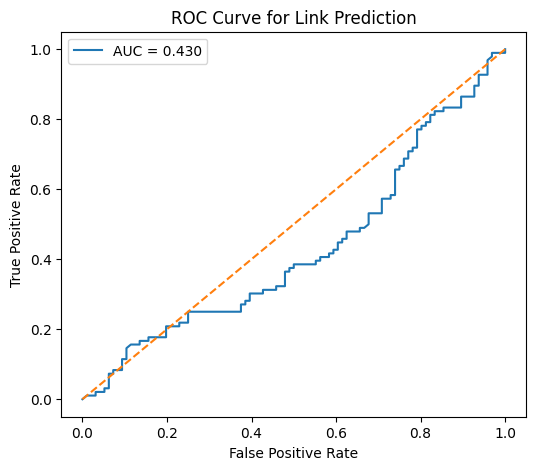

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Positive scores (removed edges)
pos_scores = [score for (_, _, score) in removed_scores]

# Negative scores (non-existing edges)
neg_scores = [score for (_, _, score) in negative_scores]

# Combine scores
scores = np.array(pos_scores + neg_scores)

# Labels: 1 = true edge (removed), 0 = non-edge
labels = np.array([1]*len(pos_scores) + [0]*len(neg_scores))

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(labels, scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Link Prediction")
plt.legend()
plt.show()



## 4.f 

#### i. How effective was cosine similarity as a scoring method for predicting missing links?
In this specific experiment, cosine similarity was ineffective (AUC ~ 0.43). However, this is largely because the underlying graph is a completely random Erdős-Rényi (ER) graph, which contains no real structure. In graphs that actually possess structure (like homophily or community clusters), cosine similarity on Node2Vec embeddings is usually highly effective at ranking missing links because true missing links tend to be between structurally similar nodes.

#### ii. How might different embedding parameters (dimensions, walk length, etc.) or alternative scoring methods impact the results?
##### Embedding Parameters:
1. Increasing dimensions can capture more complex patterns but requires more data to train correctly without overfitting.
Larger walk_length and window let the model capture global community structures (nodes far apart), while smaller values restrict the embeddings strictly to local neighborhoods.
2. Changing the p (return) and q (in-out) parameters in Node2Vec biases the random walks to behave more like Breadth-First Search (local micro-structure) or Depth-First Search (global macro-structure), depending on what the network dictates.
3. lternative Scoring Methods: Instead of pure cosine similarity, we could use the Hadamard product (element-wise multiplication) or L1/L2 distance between the vectors $u$ and $v$ to create an "edge feature vector." This vector can be fed into a supervised classifier (like Random Forest or XGBoost), which usually performs much better than raw cosine similarity because it can learn non-linear combinations of the latent dimensions.

#### iii. What are the potential limitations of your current methodology, and what improvements would you suggest for future experiments?
- Limitation 1: Testing on a Random Graph. Node2Vec relies on exploiting hidden structural regularities in a graph. An Erdős-Rényi graph has none. Improvement: Test the methodology on a network with actual structure, such as a Watts-Strogatz (small-world) or a real-world dataset (e.g., social networks, citation networks) to truly gauge link prediction capacity.
- Limitation 2: Limited Scoring Mechanism. Cosine similarity treats every dimension equally and only looks at the angle between embeddings. Improvement: Use a supervised machine learning model that takes the transformed Node2Vec embeddings (e.g. Hadamard product of $u$ and $v$) as input features to distinguish true edges from non-edges.
- Limitation 3: Cold Start / Disconnected Graphs. If the removal of 20% of edges heavily fractures the graph or leaves nodes with extremely few connections, Node2Vec struggles to learn meaningful embeddings for those isolated nodes. Improvement: Use a more sophisticated splitting strategy that guarantees the train graph remains a single strongly connected component, and perhaps test against larger graphs, as Node2Vec embeddings improve as the network size scales up.